In [1]:
import gzip
import glob
import os
import multiprocessing as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate halflife

Treatment tile: 4 h

In [17]:
def get_halflife(total, nascent):
    if total == 0:
        return np.nan
    elif nascent == 0:
        return np.inf
    elif nascent == total:
        return 0
    elif nascent > total:
        assert False
    else:
        ntr = nascent / total
        return -4 / np.log2(1 - ntr)

def worker(path1, path2, outfile):
    dat1 = pd.read_csv(gzip.open(path1, "rt"), sep="\t", index_col=0)
    dat2 = pd.read_csv(gzip.open(path2, "rt"), sep="\t", index_col=0)
    dat1 = dat1[~dat1.index.duplicated()]
    dat2 = dat2[~dat2.index.duplicated()]
    s1 = dat1.sum(axis=1)
    s1.name = "Exists"
    s2 = dat2.sum(axis=1)
    s2.name = "Nascent"
    d = pd.concat([s1, s2], axis=1)
    d.index.name = "GeneName"
    d["Total"] = d["Exists"] + d["Nascent"]
    d["NTR"] = d["Nascent"] / d["Total"]
    # d["T"] = -4 / np.log2(1 - d["NTR"])
    d["T"] = [get_halflife(total, nascent) for total, nascent in d[["Total", "Nascent"]].values]
    d.to_csv(outfile, sep="\t")

pool = mp.Pool(12)
for path in glob.glob("data/GSE141851_RAW/*_C.txt.gz"):
    name = path.split("/")[-1][:-9]
    path1 = "data/GSE141851_RAW/%s_T.txt.gz" % name
    path2 = "data/GSE141851_RAW/%s_C.txt.gz" % name
    outfile = "results/halflife/%s.tsv" % name
    if os.path.exists(outfile):
        continue
    pool.apply_async(worker, (path1, path2, outfile))
pool.close()
pool.join()

In [16]:
for batch in [1, 2]:
    if batch == 1:
        params = [
            [0, "GSM4512674_mESC-b1-Chase-0min"],
            [0.5, "GSM4512675_mESC-b1-Chase-30min"],
            [1, "GSM4512676_mESC-b1-Chase-60min"],
            [3, "GSM4512677_mESC-b1-Chase-3hr"],
            [6, "GSM4512678_mESC-b1-Chase-6hr"],
            [12, "GSM4512679_mESC-b1-Chase-12hr"],
            [24, "GSM4512680_mESC-b1-Chase-24hr"],
        ]
    else:    
        params = [
            [0, "GSM4512681_mESC-b2-Chase-0min"],
            [0.5, "GSM4512682_mESC-b2-Chase-30min"],
            [1, "GSM4512683_mESC-b2-Chase-60min"],
            [3, "GSM4512684_mESC-b2-Chase-3hr"],
            [6, "GSM4512685_mESC-b2-Chase-6hr"],
            [12, "GSM4512686_mESC-b2-Chase-12hr"],
            [24, "GSM4512687_mESC-b2-Chase-24hr"],
        ]
    array = []
    for time, name in params:
        path = "results/halflife/%s.tsv" % name
        d = pd.read_csv(path, sep="\t", index_col=0)
        d = d[d["Total"] >= 100]
        s = d["NTR"]
        s.name = time
        array.append(s)

    dat = pd.concat(array, axis=1, join="inner")
    dat = dat.divide(dat[0.0], axis=0)
    Ts = []
    ts = dat.columns
    for values in dat.values:
        xs0 = ts[1:]
        ys0 = values[1:]
        if any(map(lambda v: v >= 1, ys0)):
            T = np.nan
        else:
            ys = np.log(-np.log2(ys0))
            xs = np.log(xs0)
            b = sum(ys - xs) / len(ys)
            T = 1 / (np.e ** b)
            if T < 0:
                T = np.nan
        Ts.append(T)
    dat["T"] = Ts
    dat.to_csv("results/halflife/Pulse_chase_mESC_batch%d.tsv" % batch, sep="\t")

/lustre/grp/tfclab/chenzg/tmp/ipykernel_2596807/2177759590.py:41: RuntimeWarning: divide by zero encountered in log2
  ys = np.log(-np.log2(ys0))
/lustre/grp/tfclab/chenzg/tmp/ipykernel_2596807/2177759590.py:41: RuntimeWarning: divide by zero encountered in log2
  ys = np.log(-np.log2(ys0))
/lustre/grp/tfclab/chenzg/tmp/ipykernel_2596807/2177759590.py:41: RuntimeWarning: divide by zero encountered in log2
  ys = np.log(-np.log2(ys0))
/lustre/grp/tfclab/chenzg/tmp/ipykernel_2596807/2177759590.py:41: RuntimeWarning: divide by zero encountered in log2
  ys = np.log(-np.log2(ys0))
/lustre/grp/tfclab/chenzg/tmp/ipykernel_2596807/2177759590.py:41: RuntimeWarning: divide by zero encountered in log2
  ys = np.log(-np.log2(ys0))
/lustre/grp/tfclab/chenzg/tmp/ipykernel_2596807/2177759590.py:41: RuntimeWarning: divide by zero encountered in log2
  ys = np.log(-np.log2(ys0))
/lustre/grp/tfclab/chenzg/tmp/ipykernel_2596807/2177759590.py:41: RuntimeWarning: divide by zero encountered in log2
  ys = 

# Metrics

In [7]:
path1 = "data/GSE141851_RAW/GSM4512694_K562-4SU-TFEA_T.txt.gz"
path2 = "data/GSE141851_RAW/GSM4512694_K562-4SU-TFEA_C.txt.gz"
dat1 = pd.read_csv(gzip.open(path1, "rt"), sep="\t")
dat2 = pd.read_csv(gzip.open(path2, "rt"), sep="\t")

In [16]:
# UMIs / cell
s1 = dat1.sum(axis=0)
s2 = dat2.sum(axis=0)
dat = pd.concat([s1, s2], axis=1)
vs = dat.sum(axis=1)
np.median(vs), np.mean(vs), np.std(vs)

(2401.0, 3021.7925, 2523.8311590603184)

In [30]:
# Genes / cell
vs = []
for c in dat1.columns:
    s1 = dat1[c]
    s2 = dat2[c]
    d = pd.concat([s1, s2], axis=1)
    s = d.sum(axis=1)
    n = sum(s > 0)
    vs.append(n)
np.median(vs), np.mean(vs), np.std(vs)

(1464.0, 1662.9925, 1120.1100905463488)

In [36]:
# Nascent genes / cell
d = dat2 > 0
vs = d.sum(axis=0)
np.median(vs), np.mean(vs), np.std(vs)

(714.5, 885.44875, 711.9047986728546)

In [2]:
path1 = "data/GSE141851_RAW/GSM4512694_K562-4SU-TFEA_T.txt.gz"
path2 = "data/GSE141851_RAW/GSM4512694_K562-4SU-TFEA_C.txt.gz"
d1 = pd.read_csv(gzip.open(path1, "rt"), sep="\t")
d2 = pd.read_csv(gzip.open(path2, "rt"), sep="\t")
d3 = d1 + d2

In [13]:
umis = d3.sum()
umis = umis[umis > 1000]
np.mean(umis), np.median(umis)

(3892.073949579832, 3333.0)

In [17]:
d4 = d3[umis.index]

In [21]:
genes = (d4 > 0).sum()
np.mean(genes), np.median(genes)

(2099.7781512605043, 1961.0)

In [22]:
path1 = "data/GSE141851_RAW/GSM4512697_K562-4SU-TFEA-N9_T.txt.gz"
path2 = "data/GSE141851_RAW/GSM4512697_K562-4SU-TFEA-N9_C.txt.gz"
d1 = pd.read_csv(gzip.open(path1, "rt"), sep="\t")
d2 = pd.read_csv(gzip.open(path2, "rt"), sep="\t")
d3 = d1 + d2

In [23]:
umis = d3.sum()
umis = umis[umis > 1000]
np.mean(umis), np.median(umis)

(9653.56125, 8008.5)

In [24]:
d4 = d3[umis.index]

In [25]:
genes = (d4 > 0).sum()
np.mean(genes), np.median(genes)

(3611.76875, 3437.0)

# Benchmark

/home/chenzonggui/miniconda3/envs/py36/lib/python3.6/site-packages/pandas/core/series.py:726: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


GSM4512694_K562-4SU-TFEA	1	4.037951486570006	12.968736270136828


/home/chenzonggui/miniconda3/envs/py36/lib/python3.6/site-packages/pandas/core/series.py:726: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


GSM4512694_K562-4SU-TFEA	2	3.9484484535668343	18.348766122599123


/home/chenzonggui/miniconda3/envs/py36/lib/python3.6/site-packages/pandas/core/series.py:726: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


GSM4512697_K562-4SU-TFEA-N9	1	5.973555370891373	12.937660398487672


/home/chenzonggui/miniconda3/envs/py36/lib/python3.6/site-packages/pandas/core/series.py:726: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


GSM4512697_K562-4SU-TFEA-N9	2	5.871226812711365	18.20998711855817


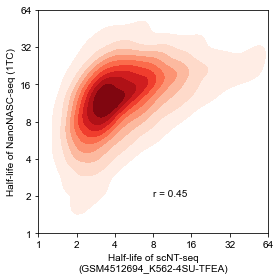

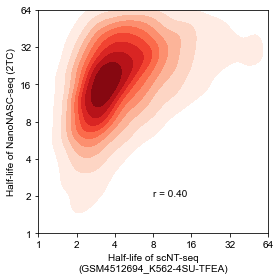

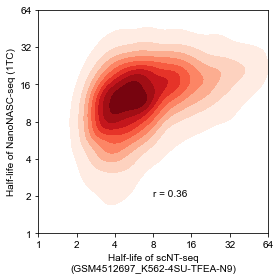

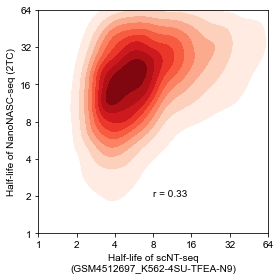

In [2]:
for name in ["GSM4512694_K562-4SU-TFEA", "GSM4512697_K562-4SU-TFEA-N9"]: # K562-4sU-TFEA and K562-4sU-TFEA-2ndSS
    for tc in [1, 2]:
        path1 = "data/GSE141851_RAW/%s_T.txt.gz" % name
        path2 = "data/GSE141851_RAW/%s_C.txt.gz" % name
        dat1 = pd.read_csv(gzip.open(path1, "rt"), sep="\t")
        dat2 = pd.read_csv(gzip.open(path2, "rt"), sep="\t")
        s1 = dat1.sum(axis=1)
        s1.name = "Exists"
        s2 = dat2.sum(axis=1)
        s2.name = "Nascent"
        d = pd.concat([s1, s2], axis=1)
        d["Total"] = d["Exists"] + d["Nascent"]
        d["NTR"] = d["Nascent"] / d["Total"]
        d["T"] = -4 / np.log2(1 - d["NTR"])
        # d.head()
        
        dat = pd.read_csv("../01_NanoNASCseq/results/halflife/NanoNASCseq_K562_50uM_3h_116cells.%dTC.tsv" % tc, sep="\t", index_col=0)
        dat = dat[~dat["GeneName"].duplicated()]
        dat.index = dat["GeneName"]

        dat = dat.merge(d, left_index=True, right_index=True, suffixes=["_NanoNASCseq", "_scNTseq"])
        dat = dat[~dat["Total_NanoNASCseq"].isna()]
        dat = dat[~dat["Total_scNTseq"].isna()]
        dat = dat[dat["Total_NanoNASCseq"] >= 50]
        dat = dat[dat["Total_scNTseq"] >= 50]
        dat = dat[dat["Nascent_NanoNASCseq"] > 0]
        dat = dat[dat["Nascent_scNTseq"] > 0]
        dat = dat[dat["T_scNTseq"] < 64]
        dat = dat[dat["T_NanoNASCseq"] < 64]
        
        xs, ys = dat["T_scNTseq"], dat["T_NanoNASCseq"]
        print(name, tc, np.median(xs), np.median(ys), sep="\t")
        xs = np.log2(xs)
        ys = np.log2(ys)
        r = np.corrcoef(xs, ys)[0][1]
        xs1 = np.arange(0, 7)
        xticks1 = [2 ** x for x in xs1]
        plt.figure(figsize=(4, 4))
        sns.kdeplot(x=xs, y=ys, fill=True, cmap='Reds', cbar=False, alpha=1, zorder=2)
        plt.text(3, 1, "r = %.2f" % r)
        plt.xlim(0, 6)
        plt.ylim(0, 6)
        plt.xticks(xs1, xticks1)
        plt.yticks(xs1, xticks1)
        plt.xlabel("Half-life of scNT-seq\n(%s)" % name)
        plt.ylabel("Half-life of NanoNASC-seq (%dTC)" % tc)
        plt.tight_layout()
        plt.savefig("figures/comparison_of_halflife.%s_NanoNASCseq_%sTC.pdf" % (name, tc), dpi=300)

# Calculate half-life (pause-chase)

mESC

In [3]:
path = "results/halflife/GSM4512689_mESC-WT-rep2.tsv"
dat = pd.read_csv(path, sep="\t", index_col=0)

In [4]:
dat1 = dat[(dat["Total"] >= 100) & (dat["NTR"] > 0) & (dat["NTR"] < 1) & (dat["T"] > 1) & (dat["T"] < 72)]
print(len(dat1))

9137


In [5]:
np.mean(dat1["T"]), np.median(dat1["T"])

(7.376244578018589, 5.086107619329495)

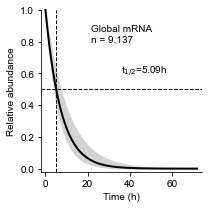

In [6]:
max_time = 72
xs = np.arange(0, max_time, 0.1)
rows = []
hts = dat1["T"]
ht = np.median(hts)
for T in hts:
    ys = [0.5**(x/T) for x in xs]
    rows.append(ys)
d = pd.DataFrame(rows)
ys = []
ys1 = []
ys2 = []
for i in d.columns:
    vs = list(sorted(d[i]))
    y = np.median(vs)
    y1 = vs[int(len(vs) * 0.25)]
    y2 = vs[int(len(vs) * 0.75)]
    ys.append(y)
    ys1.append(y1)
    ys2.append(y2)
plt.figure(figsize=(3, 3))
plt.plot(xs, ys, color="black", lw=2, clip_on=False)
plt.fill_between(xs, ys1, ys2, color="lightgrey", clip_on=False)
plt.text(max_time * 0.5, 0.6, "t$_{1/2}$=%.2fh" % ht)
plt.text(max_time * 0.3, 0.8, "Global mRNA\nn = %s" % format(len(d), ","))
plt.axhline(0.5, ls="--", lw=1, color="black")
plt.axvline(ht, ls="--", lw=1, color="black")
plt.xlim(0 - 2, max_time + 2)
plt.ylim(-0.02, 1)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.xlabel("Time (h)")
plt.ylabel("Relative abundance")
plt.tight_layout()
plt.show()

In [7]:
params = [
    [0, "GSM4512674_mESC-b1-Chase-0min"],
    [0.5, "GSM4512675_mESC-b1-Chase-30min"],
    [1, "GSM4512676_mESC-b1-Chase-60min"],
    [3, "GSM4512677_mESC-b1-Chase-3hr"],
    [6, "GSM4512678_mESC-b1-Chase-6hr"],
    [12, "GSM4512679_mESC-b1-Chase-12hr"],
    [24, "GSM4512680_mESC-b1-Chase-24hr"],
]

# params = [
#     [0, "GSM4512681_mESC-b2-Chase-0min"],
#     [0.5, "GSM4512682_mESC-b2-Chase-30min"],
#     [1, "GSM4512683_mESC-b2-Chase-60min"],
#     [3, "GSM4512684_mESC-b2-Chase-3hr"],
#     [6, "GSM4512685_mESC-b2-Chase-6hr"],
#     [12, "GSM4512686_mESC-b2-Chase-12hr"],
#     [24, "GSM4512687_mESC-b2-Chase-24hr"],
# ]

array = []
for time, name in params:
    path = "results/halflife/%s.tsv" % name
    d = pd.read_csv(path, sep="\t", index_col=0)
    d = d[d["Total"] >= 100]
    s = d["NTR"]
    s.name = time
    array.append(s)

In [8]:
dat = pd.concat(array, axis=1, join="inner")

In [9]:
dat1 = dat.divide(dat[0.0], axis=0)


,0.0,0.5,1.0,3.0,6.0,12.0,24.0
GeneName,,,,,,,
1110004F10Rik,1.0,1.056751,0.975509,0.657249,0.270804,0.071537,0.099161
1110008F13Rik,1.0,1.089537,0.920315,0.569162,0.181697,0.054062,0.000000
1110037F02Rik,1.0,0.978455,0.889347,0.508687,0.233304,0.060055,0.013098
1110038B12Rik,1.0,0.644812,0.601274,0.397668,0.194969,0.076300,0.047687
1110038F14Rik,1.0,1.054299,0.930348,0.361020,0.151304,0.085589,0.050354
...,...,...,...,...,...,...,...
Zufsp,1.0,0.888244,0.716117,0.293459,0.109736,0.069558,0.026870
Zwilch,1.0,1.002096,0.959032,0.496276,0.227470,0.073764,0.047444
Zwint,1.0,0.980559,0.882759,0.603363,0.252460,0.057813,0.016659


In [10]:
Ts = []
ts = dat1.columns
for values in dat1.values:
    xs0 = ts[1:]
    ys0 = values[1:]
    
    if any(map(lambda v: v >= 1, ys0)):
        continue
    
    ys = np.log(-np.log2(ys0))
    xs = np.log(xs0)
    b = sum(ys - xs) / len(ys)
    T = 1 / (np.e ** b)
    
    if T > 0:
        Ts.append(T)
    # print(T)
    
#     plt.figure(figsize=(3, 3))
#     plt.plot(xs0, ys0, marker="o")
#     xs1 = np.arange(0, 24, 0.1)
#     ys1 = [2**(-x/T) for x in xs1]
#     plt.plot(xs1, ys1, color="grey")
#     plt.ylim(0, 1)
#     plt.tight_layout()
#     plt.show()
#     plt.close()
    
    
#     plt.figure(figsize=(3, 3))
#     plt.plot(xs, ys, marker="o")
#     ys1 = [x + b for x in xs]
#     plt.plot(xs, ys1, color="grey")
#     plt.tight_layout()
#     plt.show()
#     plt.close()
    
    # break

/home/chenzonggui/miniconda3/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:10: RuntimeWarning: divide by zero encountered in log2
  # Remove the CWD from sys.path while we load stuff.


In [11]:
len(Ts), np.median(Ts)

(2277, 3.307714203081155)

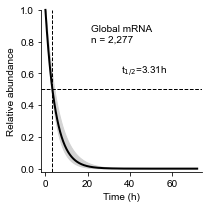

In [12]:
max_time = 72
xs = np.arange(0, max_time, 0.1)
rows = []
hts = Ts
ht = np.median(hts)
for T in hts:
    ys = [0.5**(x/T) for x in xs]
    rows.append(ys)
d = pd.DataFrame(rows)
ys = []
ys1 = []
ys2 = []
for i in d.columns:
    vs = list(sorted(d[i]))
    y = np.median(vs)
    y1 = vs[int(len(vs) * 0.25)]
    y2 = vs[int(len(vs) * 0.75)]
    ys.append(y)
    ys1.append(y1)
    ys2.append(y2)
plt.figure(figsize=(3, 3))
plt.plot(xs, ys, color="black", lw=2, clip_on=False)
plt.fill_between(xs, ys1, ys2, color="lightgrey", clip_on=False)
plt.text(max_time * 0.5, 0.6, "t$_{1/2}$=%.2fh" % ht)
plt.text(max_time * 0.3, 0.8, "Global mRNA\nn = %s" % format(len(d), ","))
plt.axhline(0.5, ls="--", lw=1, color="black")
plt.axvline(ht, ls="--", lw=1, color="black")
plt.xlim(0 - 2, max_time + 2)
plt.ylim(-0.02, 1)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.xlabel("Time (h)")
plt.ylabel("Relative abundance")
plt.tight_layout()
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x7fab1a0ef8d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fab274f5be0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fab1a0efe10>],
 'medians': [<matplotlib.lines.Line2D at 0x7fab274db588>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fab274db128>],
 'means': []}

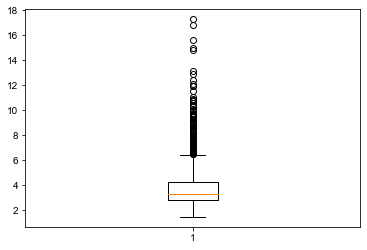

In [99]:
plt.boxplot(Ts)

# 20240911

In [27]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [137]:
mtypes = []
bases = "ACGT"
for b1 in "ACGT":
    for b2 in "ACGT":
        if b1 != b2:
            mtypes.append("%s%s" % (b1, b2))
            
for path in sorted(glob.glob("results/mismatch/03_SamToTsv/*.tsv_q27_gene_anno_stat.txt")) :
    print(path.split("/")[-1].split(".")[0])
    data = dict()
    for line in open(path):
        k, v = line.strip("\n").split("\t")
        data[k] = int(v)

    for mt in mtypes:
        n1 = data["total_%s" % mt[0]]
        n2 = data["%s_to_%s" % (mt[0], mt[1])]
        r = n2 / n1
        print(mt, n1, n2, r, sep="\t")

SRR11683990_K562-4sU
AC	504227876	190571	0.00037794618082559163
AG	504227876	457365	0.0009070601245378191
AT	504227876	183822	0.0003645613595548216
CA	445545385	122505	0.0002749551541197088
CG	445545385	95736	0.00021487373278482056
CT	445545385	325686	0.0007309827707002285
GA	456838596	428096	0.0009370836959668793
GC	456838596	122373	0.00026786922355395736
GT	456838596	151578	0.0003317977100166029
TA	482429493	194148	0.00040243808228366336
TC	482429493	468757	0.0009716590855277581
TG	482429493	123545	0.00025608923540667525
SRR11683991_K562-TFEA
AC	486334582	165070	0.0003394165377283411
AG	486334582	432736	0.0008897907243618551
AT	486334582	222395	0.00045728806511234274
CA	407024384	143711	0.00035307712670108727
CG	407024384	101516	0.0002494101188787746
CT	407024384	412649	0.0010138188674219577
GA	401675049	424259	0.0010562244308084967
GC	401675049	189570	0.0004719486571843301
GT	401675049	499664	0.0012439508036258433
TA	509971419	252415	0.0004949591106398847
TC	509971419	482471	0.00094

In [129]:
array = []
for path in sorted(glob.glob("results/signal_to_noise/ratio/SRR11683995_K562-4sU-TFEA-2ndSS/*.tsv")):
    d = pd.read_csv(path, sep="\t", index_col=0)
    d = d[["-" not in x for x in d.index]]
    if d["BaseCount"].min() > 100000:
        s = d["Ratio.NoSNP"]
        s.name = path.split("/")[-1][:-4]
        array.append(s)
m = pd.DataFrame(array)
m.index.name = "Cell"
print(len(m))

721


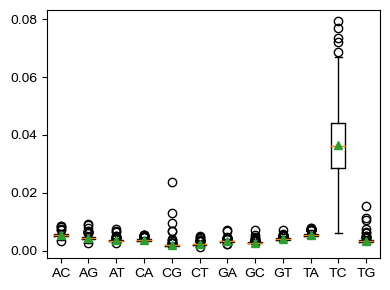

In [131]:
plt.figure(figsize=(4, 3))
plt.boxplot(m, showmeans=True)
plt.tight_layout()
plt.xticks(np.arange(len(m.columns)) + 1, m.columns)
plt.show()

In [75]:
mtypes = []
bases = "ACGT"
for b1 in "ACGT":
    for b2 in "ACGT":
        if b1 != b2:
            mtypes.append("%s%s" % (b1, b2))

In [85]:
array = []
for path in sorted(glob.glob("results/signal_to_noise/ratio/SRR11683991_K562-TFEA/*.tsv")):
    d = pd.read_csv(path, sep="\t", index_col=0)
    d = d[["-" not in x for x in d.index]]
    if d["BaseCount"].min() > 100000:
        s = d["Ratio.NoSNP"]
        s.name = path.split("/")[-1][:-4]
        array.append(s)
print(len(array))

501


In [86]:
m = pd.DataFrame(array)
m.index.name = "Cell"
print(len(m))

flags = None
for c in m.columns:
    vs = m[c]
    vs = np.sort(vs)
    lim1, lim2 = vs[int(len(vs) * 0.02)], vs[int(len(vs)*0.98)]
    flags1 = (m[c] >= lim1) & (m[c] <= lim2)
    if flags is None:
        flags = flags1
    else:
        flags = flags & flags1
m = m[flags]
print(len(m))

501
371


Type	K	R
AC	0.2997	0.1818
AG	0.6922	0.3497
AT	0.5359	0.2688
CA	0.2907	0.3472
CG	0.9344	0.3004
CT	1.0432	0.2953
GA	0.2786	0.1848
GC	0.3392	0.2981
GT	0.223	0.2083
TA	0.1517	0.3418
TC	1.0	1.0
TG	0.4523	0.2271


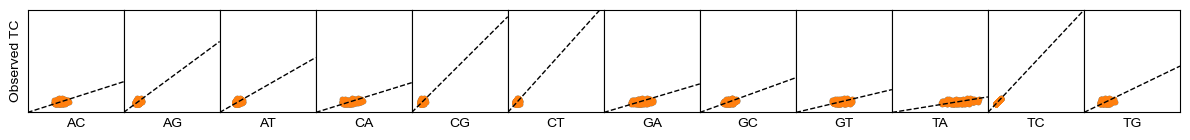

In [87]:
lim = m.max().max() * 1.1
fig, axs = plt.subplots(1, 12, figsize=(12, 1.5), sharex=True, sharey=True, gridspec_kw=dict(wspace=0))
rows = []
print("Type\tK\tR")
for i, mtype in enumerate(mtypes):
    ax = axs[i]
    plt.sca(ax)
    xs = m[mtype]
    ys = m["TC"]
    flags = (xs > lim * 0) & (ys > lim * 0)
    xs1 = xs[flags]
    ys1 = ys[flags]
    r = np.corrcoef(xs1, ys1)[0][1]
    k = np.e ** ((sum(np.log(ys1)) - sum(np.log(xs1))) / len(xs1))
    print(mtype, round(k, 4), round(r, 4),sep="\t")
    rows.append([mtype, k, r])
    plt.scatter(xs, ys, marker=".")
    plt.scatter(xs1, ys1, marker=".")
    plt.plot([0, lim], [0, lim * k], lw=1, ls="--", color="black")
    plt.xlim(0, lim)
    plt.ylim(0, lim)
    plt.xticks([])
    plt.yticks([])
    plt.xlabel(mtype)
    if i == 0:
        plt.ylabel("Observed TC")
plt.tight_layout()
plt.show()

In [88]:
model = pd.DataFrame(rows, columns=["Type", "K", "R"])
model = model[(model["Type"] != "TC") & (model["R"] >= 0.3)]
model["W"] = model["R"] / model["R"].sum()
# model.to_csv("reports/Estimate.Pe.Model.scNTseq.tsv", sep="\t", index=False)
print("Model:")
print(model)

Model:
  Type         K         R         W
1   AG  0.692240  0.349713  0.261141
3   CA  0.290656  0.347181  0.259250
4   CG  0.934365  0.300438  0.224346
9   TA  0.151683  0.341841  0.255263


In [89]:
array = []
for t, k, r, w in model.values:
    array.append(m[t] * k * w)
m1 = m.copy()
m1["Pe"] = pd.DataFrame(array).sum(axis=0)

Custom strategy
K: 0.9975, R: 0.4287
NASC-seq strategy
K: 0.4390, R: 0.2316
GRAND-SLAM strategy
K: 0.2268, R: 0.3481


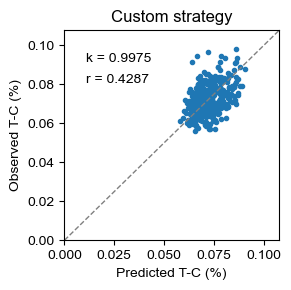

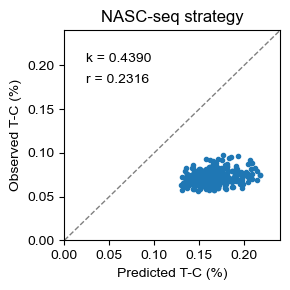

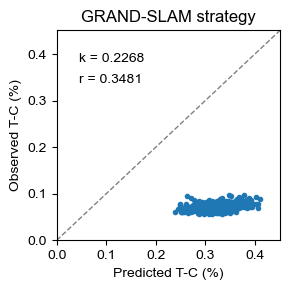

In [90]:
params = [
    ["Custom strategy", m1["Pe"], m1["TC"]],
    ["NASC-seq strategy", (m1["CT"] + m1["GA"]) / 2, m1["TC"]],
    ["GRAND-SLAM strategy", ((m1["TA"] + m1["TG"]) / 2), m1["TC"]]
]
for i, (name, xs, ys) in enumerate(params):
    print(name)
    xs, ys = xs * 100, ys * 100
    lim = max(max(xs), max(ys)) * 1.1
    r = np.corrcoef(xs, ys)[0][1]
    k = np.e ** ((sum(np.log(ys)) - sum(np.log(xs))) / len(xs))
    print("K: %.4f, R: %.4f" % (k, r))
    plt.figure(figsize=(3, 3))
    plt.title(name)
    plt.scatter(xs, ys, marker=".")
    plt.plot([0, lim], [0, lim], lw=1, color="grey", ls="--")
    plt.text(lim * 0.1, lim * 0.85, "k = %.4f" % k)
    plt.text(lim * 0.1, lim * 0.75, "r = %.4f" % r)
    plt.xlim(0, lim)
    plt.ylim(0, lim)
    # plt.xticks([])
    # plt.yticks([])
    plt.xlabel("Predicted T-C (%)")
    plt.ylabel("Observed T-C (%)")
    plt.tight_layout()
    # plt.savefig("figures/predict_observed_tc_ratio.%s.png" % name.split()[0])

In [112]:
array = []
for path in sorted(glob.glob("results/signal_to_noise/pc/SRR11683990_K562-4sU/*.tsv")):
    d = pd.read_csv(path, sep="\t")
    d.index = [path.split("/")[-1][:-4]]
    array.append(d)
d1 = pd.concat(array)

array = []
for path in sorted(glob.glob("results/signal_to_noise/pc/SRR11683992_K562-4sU-TFEA/*.tsv")):
    d = pd.read_csv(path, sep="\t")
    d.index = [path.split("/")[-1][:-4]]
    array.append(d)
d2 = pd.concat(array)

1.095342034582837 29.929634827344998


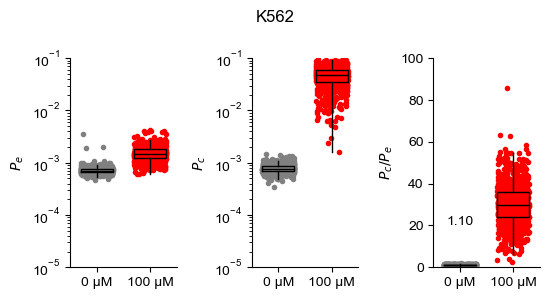

In [114]:
s4u = 100
ticks = ["0 μM", "100 μM"]

d1 = d1[~(d1["Pe"].isna() | d1["Pc"].isna())]
d2 = d2[~(d2["Pe"].isna() | d2["Pc"].isna())]
    
np.random.seed(0)

pc1, pe1 = d1["Pc"], d1["Pe"]
pc2, pe2 = d2["Pc"], d2["Pe"]

colors = ["grey", "red"]

w = 0.6
    
fig, axs = plt.subplots(1, 3, figsize=(5.6, 3))
fig.suptitle("K562")

plt.sca(axs[0])
ys_list = [pe1, pe2]
plt.boxplot(ys_list, positions=[0, 1], widths=w, 
            showcaps=False, showfliers=False, medianprops={"color": "black"})
for x, ys in enumerate(ys_list):
    xs = np.random.rand(len(ys)) * w + x - w/2
    plt.scatter(xs, ys, marker=".", color=colors[x])
plt.gca().set_yscale("log")
plt.xticks([0, 1], ticks)
plt.ylim(0.00001, 0.1)
# plt.ylabel(r"$\it{P}$$_{\mathit{e}}$")
# plt.ylabel(r"${\it{P}}_{\mathit{e}}$")
plt.ylabel(r'$P_e$')

plt.sca(axs[1])
ys_list = [pc1, pc2]
plt.boxplot(ys_list, positions=[0, 1], widths=w, 
            showcaps=False, showfliers=False, medianprops={"color": "black"})
for x, ys in enumerate(ys_list):
    xs = np.random.rand(len(ys)) * w + x - w/2
    plt.scatter(xs, ys, marker=".", color=colors[x])
plt.gca().set_yscale("log")
plt.xticks([0, 1], ticks)
plt.ylim(0.00001, 0.1)
plt.ylabel(r'$P_c$')

plt.sca(axs[2])
ys_list = [pc1 / pe1, pc2 / pe2]
print(np.median(ys_list[0]), np.median(ys_list[1]))
plt.boxplot(ys_list, positions=[0, 1], widths=w, 
            showcaps=False, showfliers=False, medianprops={"color": "black"})
for x, ys in enumerate(ys_list):
    xs = np.random.rand(len(ys)) * w + x - w/2
    plt.scatter(xs, ys, marker=".", color=colors[x])
plt.text(0, 20, "%.2f" % np.median(ys_list[0]), ha="center")
# plt.gca().set_yscale("log")
plt.xticks([0, 1], ticks)
ylim = 100
plt.ylim(0, ylim)
plt.ylabel(r'$P_c/P_e$')

for ax in axs:
    for loc in ["top", "right"]:
        ax.spines[loc].set_visible(False)

plt.tight_layout()
# plt.savefig("figures/signal_to_noise.%s.pdf" % cell_line)
# break

In [119]:
print("scNT-seq")
print("Pc/Pe (mean):", np.mean(d2["Pc/Pe"]))
print("Pc/Pe (median):", np.median(d2["Pc/Pe"]))

scNT-seq
Pc/Pe (mean): 30.289481032758466
Pc/Pe (median): 29.929634827343463
